In [13]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import RBFInterpolator
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from chemlib import Compound
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.ticker as ticker

from main_file import (
    get_molar_masses,
    get_jarosite_params,
    CompositionCalculator,
    SolutionState,
)

from interp import (
    WaterPropertiesInterpolator,
    MgSO4ConstantInterpolator,
    H2SO4ConstantInterpolator,
    MgSO4SolubilityInterpolator,
    clean_experimental_data_local_outliers,
)


In [14]:
# Получить молярные массы
molar_masses = get_molar_masses()

# Диапазон температур и степеней окисления серы
T_values = np.linspace(298.15, 513.15, 50)
S_Ox_values = np.linspace(0.2, 1, 50)

# Для построения трехмерных графиков
T_grid, S_Ox_grid = np.meshgrid(T_values, S_Ox_values)

# Получить параметры ярозитов
jarosite_params = get_jarosite_params(molar_masses)

# Инициализировать интерполятор свойств воды
water_props = WaterPropertiesInterpolator()


# Параметры эксперимента
Ж_Т = 2
mass_ore = 26.6 * 10 ** 6  # г
Mg_S = 0.6  # 60% от массы серы
Fe_Ox = 0.9  # 90% железа окисляется
H2SO4_add_percent = 0.2  # 20% от массы воды

# Состав руды (массовые проценты)
Fe_w = 20.4
S_w = 21.2
As_w = 6.8
K_w = 0.1
NH4_w = 0.2


In [15]:
calc = CompositionCalculator(molar_masses)
ore_data = calc.calculate_ore_composition(
    Fe_w, S_w, As_w, K_w, NH4_w,
    mass_ore, Ж_Т, Mg_S, Fe_Ox,
    H2SO4_add_percent
)

# Создать таблицу результатов
results_df = pd.DataFrame({
    'Вещество': ['Fe', 'S', 'As', 'K', 'NH4', 'H3O', 'FeS2', 'FeAsS', 'Mg(OH)2', 'H2SO4', 'MgSO4'],
    'Молярная масса, г/моль': [
        molar_masses['Fe'],
        molar_masses['S'],
        molar_masses['As'],
        molar_masses['K'],
        molar_masses['NH4'],
        molar_masses['H3O'],
        molar_masses['FeS2'],
        molar_masses['FeAsS'],
        molar_masses['Mg(OH)2'],
        molar_masses['H2SO4'],
        molar_masses['MgSO4'],
    ],
})

print(results_df)

   Вещество  Молярная масса, г/моль
0        Fe                  55.845
1         S                  32.065
2        As                  74.922
3         K                  39.098
4       NH4                  18.039
5       H3O                  19.020
6      FeS2                 119.975
7     FeAsS                 162.832
8   Mg(OH)2                  58.319
9     H2SO4                  98.077
10    MgSO4                 120.366


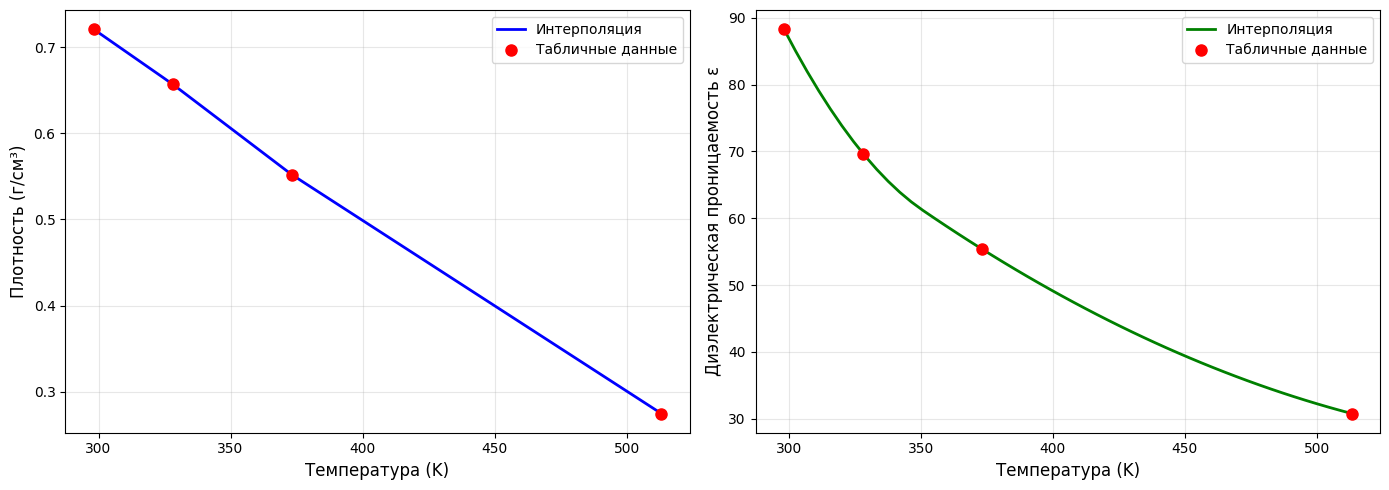

In [16]:
# Вычисляем значения
density_values = [water_props.get_density(T) for T in T_values]
epsilon_values = [water_props.get_dielectric(T) for T in T_values]

# Создаем два графика рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График плотности
ax1.plot(T_values, density_values, 'b-', linewidth=2, label='Интерполяция')
ax1.plot(water_props.table_temps_K, water_props.table_density, 'ro', 
         markersize=8, label='Табличные данные')
ax1.set_xlabel('Температура (K)', fontsize=12)
ax1.set_ylabel('Плотность (г/см³)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# График диэлектрической проницаемости
ax2.plot(T_values, epsilon_values, 'g-', linewidth=2, label='Интерполяция')
ax2.plot(water_props.table_temps_K, water_props.table_epsilon, 'ro', 
         markersize=8, label='Табличные данные')
ax2.set_xlabel('Температура (K)', fontsize=12)
ax2.set_ylabel('Диэлектрическая проницаемость ε', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
# Создаем интерполятор для H2SO4
h2so4_interp = H2SO4ConstantInterpolator('data.xlsx', 'Equilibrium constants_H2SO4')
h2so4_interp.prepare_data()

# Создаем интерполяторы для MgSO4
mgso4_K_interp = MgSO4ConstantInterpolator('data.xlsx', 'Equilibrium constants_MgSO4')
mgso4_K_interp.prepare_data()

mgso4_sol_interp = MgSO4SolubilityInterpolator('data.xlsx', 'Experimental_sol_Mg_SO4')
mgso4_sol_interp.prepare_data()

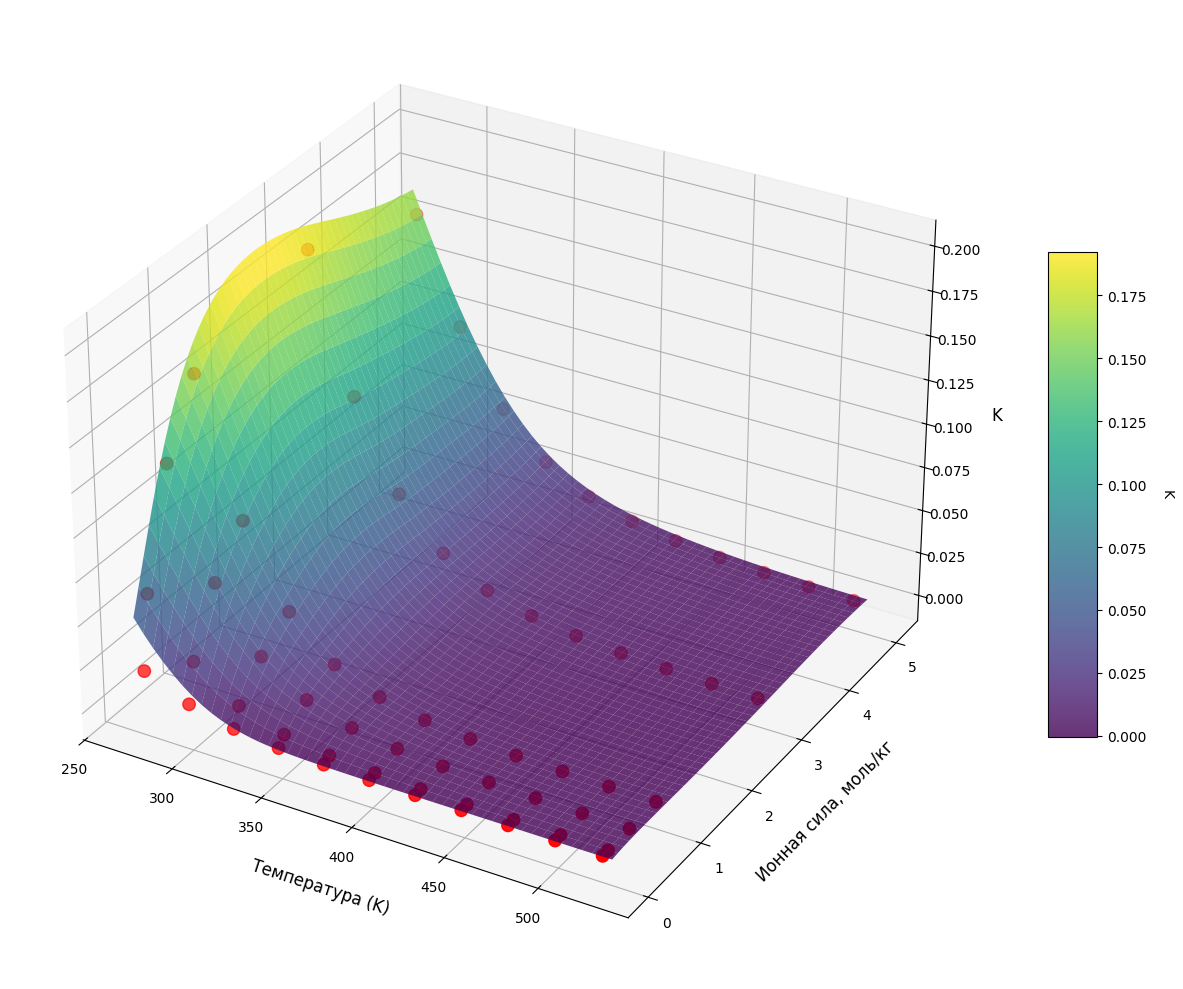

In [18]:
n_points = 50

T_min, T_max = h2so4_interp.points[:, 0].min(), h2so4_interp.points[:, 0].max()
I_min, I_max = h2so4_interp.points[:, 1].min(), h2so4_interp.points[:, 1].max()
    
# Добавляем небольшой запас
T_range = [T_min - 5, T_max + 5]
I_range = [max(0, I_min - 0.1), I_max + 0.1]
    
# Создаем сетку
T_grid, I_grid = np.meshgrid(
    np.linspace(T_range[0], T_range[1], n_points),
    np.linspace(I_range[0], I_range[1], n_points)
)
    
# Вычисляем K
K_grid = np.zeros_like(T_grid)
for i in range(n_points):
    for j in range(n_points):
        K_grid[i, j] = h2so4_interp.get_K(T_grid[i, j], I_grid[i, j])
    
# Создаем график
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
    
# Поверхность
surf = ax.plot_surface(T_grid, I_grid, K_grid, 
                           cmap='viridis', alpha=0.8,
                           linewidth=0, antialiased=True)
    
# Исходные точки
ax.scatter(h2so4_interp.points[:, 0], 
               h2so4_interp.points[:, 1], 
               h2so4_interp.K,
               color='red', s=80, label='Исходные данные')
    
# Настройки
ax.set_xlabel('Температура (K)', fontsize=12, labelpad=10)
ax.set_ylabel('Ионная сила, моль/кг', fontsize=12, labelpad=10)
ax.set_zlabel('K', fontsize=12, labelpad=10)
    
# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('K', rotation=270, labelpad=20)
    
plt.tight_layout()


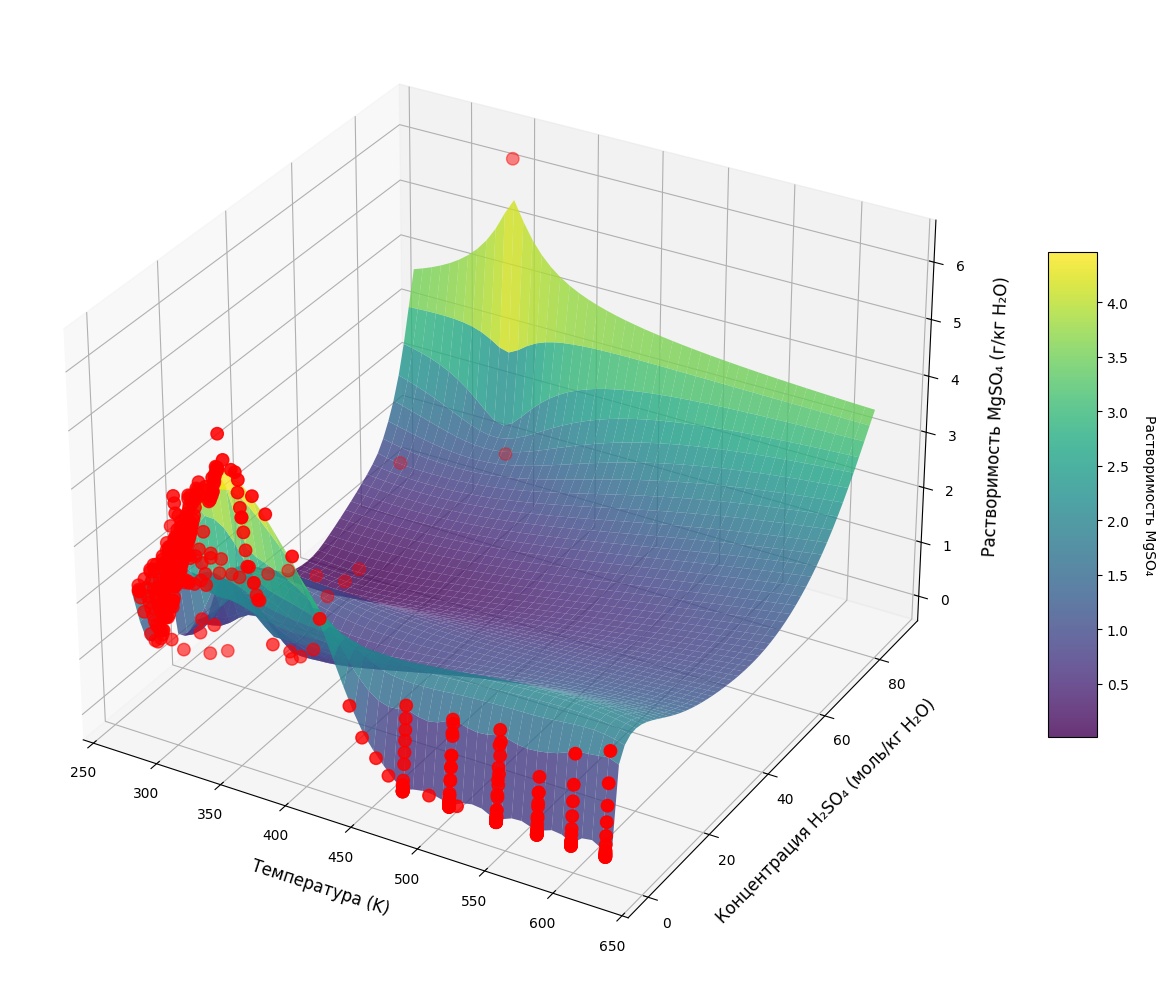

In [19]:
n_points = 50

T_min, T_max = mgso4_sol_interp.points[:, 0].min(), mgso4_sol_interp.points[:, 0].max()
H2SO4_min, H2SO4_max = mgso4_sol_interp.points[:, 1].min(), mgso4_sol_interp.points[:, 1].max()
    
# Добавляем небольшой запас
T_range = [T_min - 5, T_max + 5]
H2SO4_range = [max(0, H2SO4_min - 0.1), H2SO4_max + 0.1]
    
# Создаем сетку
T_grid, H2SO4_grid = np.meshgrid(
    np.linspace(T_range[0], T_range[1], n_points),
    np.linspace(H2SO4_range[0], H2SO4_range[1], n_points)
)
    
# Вычисляем растворимость
Sol_grid = np.zeros_like(T_grid)
for i in range(n_points):
    for j in range(n_points):
        Sol_grid[i, j] = mgso4_sol_interp.get_sol(T_grid[i, j], H2SO4_grid[i, j])
    
# Создаем график
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
    
# Поверхность
surf = ax.plot_surface(T_grid, H2SO4_grid, Sol_grid, 
                           cmap='viridis', alpha=0.8,
                           linewidth=0, antialiased=True)
    
# Исходные точки
ax.scatter(mgso4_sol_interp.points[:, 0], 
               mgso4_sol_interp.points[:, 1], 
               mgso4_sol_interp.MgSO4_sol,
               color='red', s=80, label='Исходные данные')
    
# Настройки
ax.set_xlabel('Температура (K)', fontsize=12, labelpad=10)
ax.set_ylabel('Концентрация H₂SO₄ (моль/кг H₂O)', fontsize=12, labelpad=10)  # Исправлено
ax.set_zlabel('Растворимость MgSO₄ (г/кг H₂O)', fontsize=12, labelpad=10)  # Исправлено
    
# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Растворимость MgSO₄', rotation=270, labelpad=20)
    
plt.tight_layout()



In [20]:
# Функция расчета для конкретных T и S_Ox с возможностью добавки H2SO4 или брусита для разных ярозитов
def calculate_for_T_and_S_Ox(self, T, S_Ox, add_H2SO4=False, add_MgOH=False, jarosite_type='ion_name'):
    jar_params = jarosite_params[jarosite_type]
    dH0 = jar_params['dH0']
    dS0 = jar_params['dS0']

    # 1. ОСНОВНЫЕ РЕАКЦИИ ОКИСЛЕНИЯ МИНЕРАЛОВ
    # 1.1. Окисление пирита (зависит от степени окисления серы)
    n_Fe2_pyr = self.n_FeS2 * S_Ox
    n_SO4_pyr = 2 * self.n_FeS2 * S_Ox
    n_H_pyr = 2 * self.n_FeS2 * S_Ox

    # 1.2. Окисление арсенопирита
    n_Fe2_ars = self.n_FeAsS
    n_SO4_ars = self.n_FeAsS
    n_H_ars = 3 * self.n_FeAsS
    n_AsO4_ars = self.n_FeAsS
    
    #количество ионов серной кислоты после окисления
    n_SO4_free = n_SO4_pyr + n_SO4_ars + self.n_S_excess
    n_H_free = n_H_pyr + n_H_ars
    
    #концентрация кислоты после окисления (считаем по сульфат-ионам)
    C_SO4_free = n_SO4_free / self.mass_liquid
    
    # 1.3 ОКИСЛЕНИЕ Fe²⁺ до Fe³⁺
    # все железо в руде
    n_Fe2_tot = n_Fe2_ars + n_Fe2_pyr +  self.n_Fe_excess
    
    # все железо, способное окислиться 
    n_Fe2_Ox = n_Fe2_tot * Fe_Ox
    
    # если водород в избытке, количество окисленного железа равно всему, которое способно к окислению
    if  n_H_free >  n_Fe2_Ox:
        n_H_consumed_Fe_ox = n_Fe2_Ox
        n_Fe3_tot = n_Fe2_Ox
        n_Fe2_left = n_Fe2_tot - n_Fe2_Ox #неокисленное железо
    # если железо в избытке, количество окисленного железа равно количеству водорода    
    else:
        n_H_consumed_Fe_ox = n_H_free
        n_Fe3_tot = n_H_free
        n_Fe2_left = n_Fe2_tot - n_Fe3_tot #неокисленное железо
    
    # 1.4 Окисленное железо осаждается в скородит
    if n_AsO4_ars > n_Fe3_tot:
        n_Fe3_FeAsO4 = 1 * n_Fe3_tot
        n_As_left = n_AsO4_ars - n_Fe3_FeAsO4
    else:
        n_Fe3_FeAsO4 = n_AsO4_ars
        n_As_left = 0
    
    n_H_free = n_H_free - n_H_consumed_Fe_ox
    n_H2SO4_add = 0
    n_SO4_added = 0
    # 2. ДОБАВКА H2SO4
    if add_H2SO4==True:
        n_H2SO4_add = (self.m_H2SO4_add * 1000) / self.M['H2SO4']  
        n_H_added = 2 * n_H2SO4_add
        n_SO4_added = n_H2SO4_add
        
    n_SO4_MgSO4_tot = 0
    n_MgSO4_aq = 0
    n_H_MgSO4_free = 0
    n_MgSO4_tot = 0
    n_MgSO4_prec = 0
    n_OH = 0
    
    # 3. ДОБАВКА Mg(OH)2 
    if add_MgOH==True:
        # Переводим массу Mg(OH)2 в моли
        n_MgOH_added = self.m_MgOH_add / self.M['Mg(OH)2']  
        n_OH_added = 2 * n_MgOH_added
        
        # Брусит нейтрализует кислоту: Mg(OH)2 + 2H⁺ → Mg²⁺ + 2H2O
        # Количество водорода, потребляемого после добавления брусита
        if n_H_free > n_OH_added:
            n_H_MgSO4 = n_OH_added
            n_MgSO4_tot = n_OH_added / 2
        else:
            n_H_MgSO4 = n_H_free
            n_MgSO4_tot = n_H_free / 2
        
        n_SO4_MgSO4_tot = n_MgSO4_tot  # Ионов сульфата на образование сульфата магния
        n_H_MgSO4_free = n_H_free - n_H_MgSO4 # Осталось ионов водорода после нейтрализации
        n_MgOH_left = n_MgOH_added - n_MgSO4_tot # Осталось брусита, когда вся кислота потрачена
        n_OH = 2 * n_MgOH_left
        #учитываем растворимость, находим количество растворенного сульфата магния
        if n_SO4_MgSO4_tot < mgso4_sol_interp.get_sol(T, C_SO4_free)*self.mass_liquid:
            n_MgSO4_aq = n_SO4_MgSO4_tot
        else:
            n_MgSO4_aq = mgso4_sol_interp.get_sol(T, C_SO4_free)*self.mass_liquid
        
        #выводим количество MgSO4 в осадке
        n_MgSO4_prec = n_MgSO4_tot - n_MgSO4_aq
    
    # 4. ОБЩИЕ БАЛАНСЫ 
    n_Fe2 = n_Fe2_left
    n_SO4 = n_SO4_free - n_MgSO4_prec + n_SO4_added
    n_H = n_H_free - (n_H_MgSO4 if add_MgOH==True else 0) + (n_H_added if add_H2SO4==True else 0)
    n_Fe3 = n_Fe3_tot - n_Fe3_FeAsO4
    n_Mg2 = (n_MgSO4_aq if add_MgOH==True else 0)

    # Концентрации
    C_Fe3 = n_Fe3 / self.mass_liquid
    C_H = n_H / self.mass_liquid
    C_SO4 = n_SO4 / self.mass_liquid
    C_Fe2 = n_Fe2 / self.mass_liquid
    C_Mg2 = n_Mg2 / self.mass_liquid
    C_K = self.m_K * S_Ox / self.M['K'] / self.mass_liquid 
    C_NH4 = self.m_NH4 / self.M['NH4'] / self.mass_liquid
    C_OH = n_OH / self.mass_liquid

    return {
        'T': T,
        'S_Ox': S_Ox,
        'add_H2SO4': add_H2SO4,
        'add_MgOH': add_MgOH,
        'jarosite_type': jarosite_type,
        
        'C_H': C_H,
        'C_Fe2': C_Fe2,
        'C_Fe3': C_Fe3,
        'C_SO4': C_SO4,
        'C_Mg2': C_Mg2,
        'C_K': C_K,
        'C_NH4': C_NH4,
        'C_OH': C_OH,
        
    }

In [21]:
'''Визуализация работы функции расчета концентраций'''
T_test = 513
S_Ox_test = 1

calc = CompositionCalculator(molar_masses)
calc.calculate_ore_composition(Fe_w, S_w, As_w, K_w, NH4_w,
                                   mass_ore, Ж_Т, Mg_S, Fe_Ox,
                                   H2SO4_add_percent) 

calculate_for_T_and_S_Ox(calc, T_test, S_Ox_test, add_H2SO4=False, add_MgOH=False, jarosite_type='K')

{'T': 513,
 'S_Ox': 1,
 'add_H2SO4': False,
 'add_MgOH': False,
 'jarosite_type': 'K',
 'C_H': 0.27365974565856954,
 'C_Fe2': 0.020294266869609317,
 'C_Fe3': 0.13222559173361703,
 'C_SO4': 0.3673094582185491,
 'C_Mg2': 0.0,
 'C_K': 0.0014209308802382618,
 'C_NH4': 0.0061594939359782205,
 'C_OH': 0.0}

In [23]:
results = {}

jarosite_types = ['K', 'H3O', 'NH4']
scenarios = ['no_add', 'with_acid', 'with_bruc']

for j_type in jarosite_types:
    results[j_type] = {}  
    for scenario in scenarios:
        results[j_type][scenario] = {
            'report': np.empty((len(S_Ox_values), len(T_values)), dtype=object),
            'balance_check': np.empty((len(S_Ox_values), len(T_values)), dtype=object)
        }



In [ ]:

def check_mass_balance(result, T, S_Ox, add_H2SO4, add_MgOH, jarosite_type):
    
    incoming_Fe = m_Fe / M_Fe
    incoming_S = m_S / M_S + ((result.get('n_SO4_added',0) if add_H2SO4 else 0))
    incoming_As = m_As / M_As

    
    # Вычисляем исходящие потоки (моль)
    # Концентрации переводим в моли
    Fe3_out = result.get('C_Fe3', 0) * mass_liquid 
    Fe2_out = result.get('C_Fe2', 0) * mass_liquid
    Fe_in_FeAsO4 = result.get('n_Fe3_FeAsO4',0)
    Fe_in_pyr = n_FeS2 * (1 - S_Ox)
    S_in_pyr = 2*n_FeS2 * (1 - S_Ox)
    S_in_sol = result.get('C_SO4', 0) * mass_liquid
    outgoing_Fe = Fe3_out + Fe2_out + Fe_in_FeAsO4 + Fe_in_pyr
    outgoing_S = S_in_sol + S_in_pyr + result.get('n_SO4_MgSO4_tot', 0) - result.get('n_MgSO4_aq', 0)
    outgoing_As = result.get('n_AsO4_ars', 0) + result.get('n_As_left')

    # 4. Проверяем балансы
    balance_errors = []
    
    # Баланс по железу
    Fe_diff = abs(incoming_Fe - outgoing_Fe )
    if Fe_diff / incoming_Fe > 0.01:  # 1% погрешность
        balance_errors.append(f"Fe: {Fe_diff/incoming_Fe*100:.2f}% ошибка")
    
    # Баланс по сере
    S_diff = abs(incoming_S - outgoing_S )
    if S_diff / incoming_S > 0.01:
        balance_errors.append(f"S: {S_diff/incoming_S*100:.2f}% ошибка")
    
    # Баланс по мышьяку
    As_diff = abs(incoming_As - outgoing_As )
    if As_diff / incoming_As > 0.01:
        balance_errors.append(f"As: {As_diff/incoming_S*100:.2f}% ошибка")
    
    # 5. Собираем результаты проверки
    balance_check = {
         'valid': len(balance_errors) == 0,
        'errors': balance_errors,
        'details': {
            'Fe_in': incoming_Fe,
            'Fe_out': outgoing_Fe,
            'Fe3_out': Fe3_out,
            'Fe2_out': Fe2_out,
            'Fe_in_FeAsO4': Fe_in_FeAsO4,
            'Fe_in_pyr': Fe_in_pyr,
            'S_in_sol': S_in_sol,
            'S_in': incoming_S,
            'S_out': outgoing_S,
            'As_in': incoming_As,
            'As_out': outgoing_As,
            'Fe_balance_error_%': Fe_diff/incoming_Fe*100 if incoming_Fe > 0 else 0,
            'S_balance_error_%': S_diff/incoming_S*100 if incoming_S > 0 else 0,
            'As_balance_error_%': As_diff/incoming_As*100 if incoming_As > 0 else 0,
        },
        'Баланс_корректен': len(balance_errors) == 0,
        'Баланс_Fe_%': Fe_diff/incoming_Fe*100 if incoming_Fe > 0 else 0,
        'Баланс_S_%': S_diff/incoming_S*100 if incoming_S > 0 else 0,
        'Баланс_As_%': As_diff/incoming_As*100 if incoming_As > 0 else 0,
        'Fe_вх_моль': incoming_Fe,
        'Fe_вых_моль': outgoing_Fe,
        'Fe3_out': Fe3_out,
        'Fe2_out': Fe2_out,
        'Fe_in_pyr': Fe_in_pyr,
        'S_вх_моль': incoming_S,
        'S_вых_моль': outgoing_S,
        'S_in_sol': S_in_sol,
        'As_вх_моль': incoming_As,
        'As_вых_моль': outgoing_As,
        'Статус_Fe': '✅ OK' if incoming_Fe > 0 and Fe_diff/incoming_Fe <= 0.01 else '❌ Ошибка',
        'Статус_S': '✅ OK' if incoming_S > 0 and S_diff/incoming_S <= 0.01 else '❌ Ошибка',
        'Статус_As': '✅ OK' if incoming_As > 0 and As_diff/incoming_As <= 0.01 else '❌ Ошибка'
        
    }

    return balance_check
  

In [ ]:
def run_scenario(j_type, T, S_Ox, add_H2SO4, add_MgOH, scenario_name, results, i, j):
    result = calculate_for_T_and_S_Ox(self, T, S_Ox, 
                                     add_H2SO4=add_H2SO4, 
                                     add_MgOH=add_MgOH,
                                     jarosite_type=j_type)
    results[j_type][scenario_name]['report'][i, j] = result
    
    balance = check_mass_balance(result, T, S_Ox, 
                                add_H2SO4=add_H2SO4, 
                                add_MgOH=add_MgOH, 
                                jarosite_type=j_type)
    results[j_type][scenario_name]['balance_check'][i, j] = balance
    return result, balance

for var in ['i', 'j', 'i_SOx', 'j_T']:
    if var in globals():
        del globals()[var]

for j_type in jarosite_types:
    for idx_S in range(len(S_Ox_values)):    
        for idx_T in range(len(T_values)):  
            T = T_values[idx_T]
            S_Ox = S_Ox_values[idx_S]
            
            run_scenario(j_type, T, S_Ox, False, False, 'no_add', 
                        results, idx_S, idx_T)
            run_scenario(j_type, T, S_Ox, True, False, 'with_acid', 
                        results, idx_S, idx_T)
            run_scenario(j_type, T, S_Ox, False, True, 'with_bruc', 
                        results, idx_S, idx_T)

TypeError: calculate_for_T_and_S_Ox() missing 1 required positional argument: 'S_Ox'

In [ ]:
with pd.ExcelWriter('jarosite_results.xlsx', engine='openpyxl') as writer:
    all_data = []
    for j_type in jarosite_types:
        print(f"Экспортирую {jarosite_params[j_type]['name']}...")
        
        for j_type in jarosite_types:
            print(f"Экспортирую {j_type}...")
            
            rows = []
            
            for scenario in scenarios:
                for i in range(len(S_Ox_range)):
                    for j in range(len(temps_range)):
                        
                        # Получаем отчет
                        report = results[j_type][scenario]['report'][i, j]
                
                            
                        # Получаем баланс
                        balance = results[j_type][scenario]['balance_check']
                        if isinstance(balance, np.ndarray):
                            balance = balance[i, j] or {}
                        else:
                            balance = balance.get((i, j), {})
                        
                        # Базовая строка с основными полями
                        row = {
                            'Сценарий': scenario,
                            'T_°C': temps_range[j] - 273.15,
                            'S_ox_%': S_Ox_range[i] * 100,
                            **{k: v for k, v in report.items() if k != 'T_C'},  # все поля из отчета
                            **{f'balance_{k}': v for k, v in balance.items()}  # поля баланса с префиксом
                        }
                        rows.append(row)
            
            if rows:
                df = pd.DataFrame(rows)
                df.to_excel(writer, sheet_name=j_type, index=False)
                print(f"  ✓ {len(rows)} строк")
                all_data.append(row)

Экспортирую K-ярозит...
Экспортирую K...
  ✓ 300 строк
Экспортирую H3O...
  ✓ 300 строк
Экспортирую NH4...
  ✓ 300 строк
Экспортирую H₃O-ярозит...
Экспортирую K...
  ✓ 300 строк
Экспортирую H3O...
  ✓ 300 строк
Экспортирую NH4...
  ✓ 300 строк
Экспортирую NH₄-ярозит...
Экспортирую K...
  ✓ 300 строк
Экспортирую H3O...
  ✓ 300 строк
Экспортирую NH4...
  ✓ 300 строк


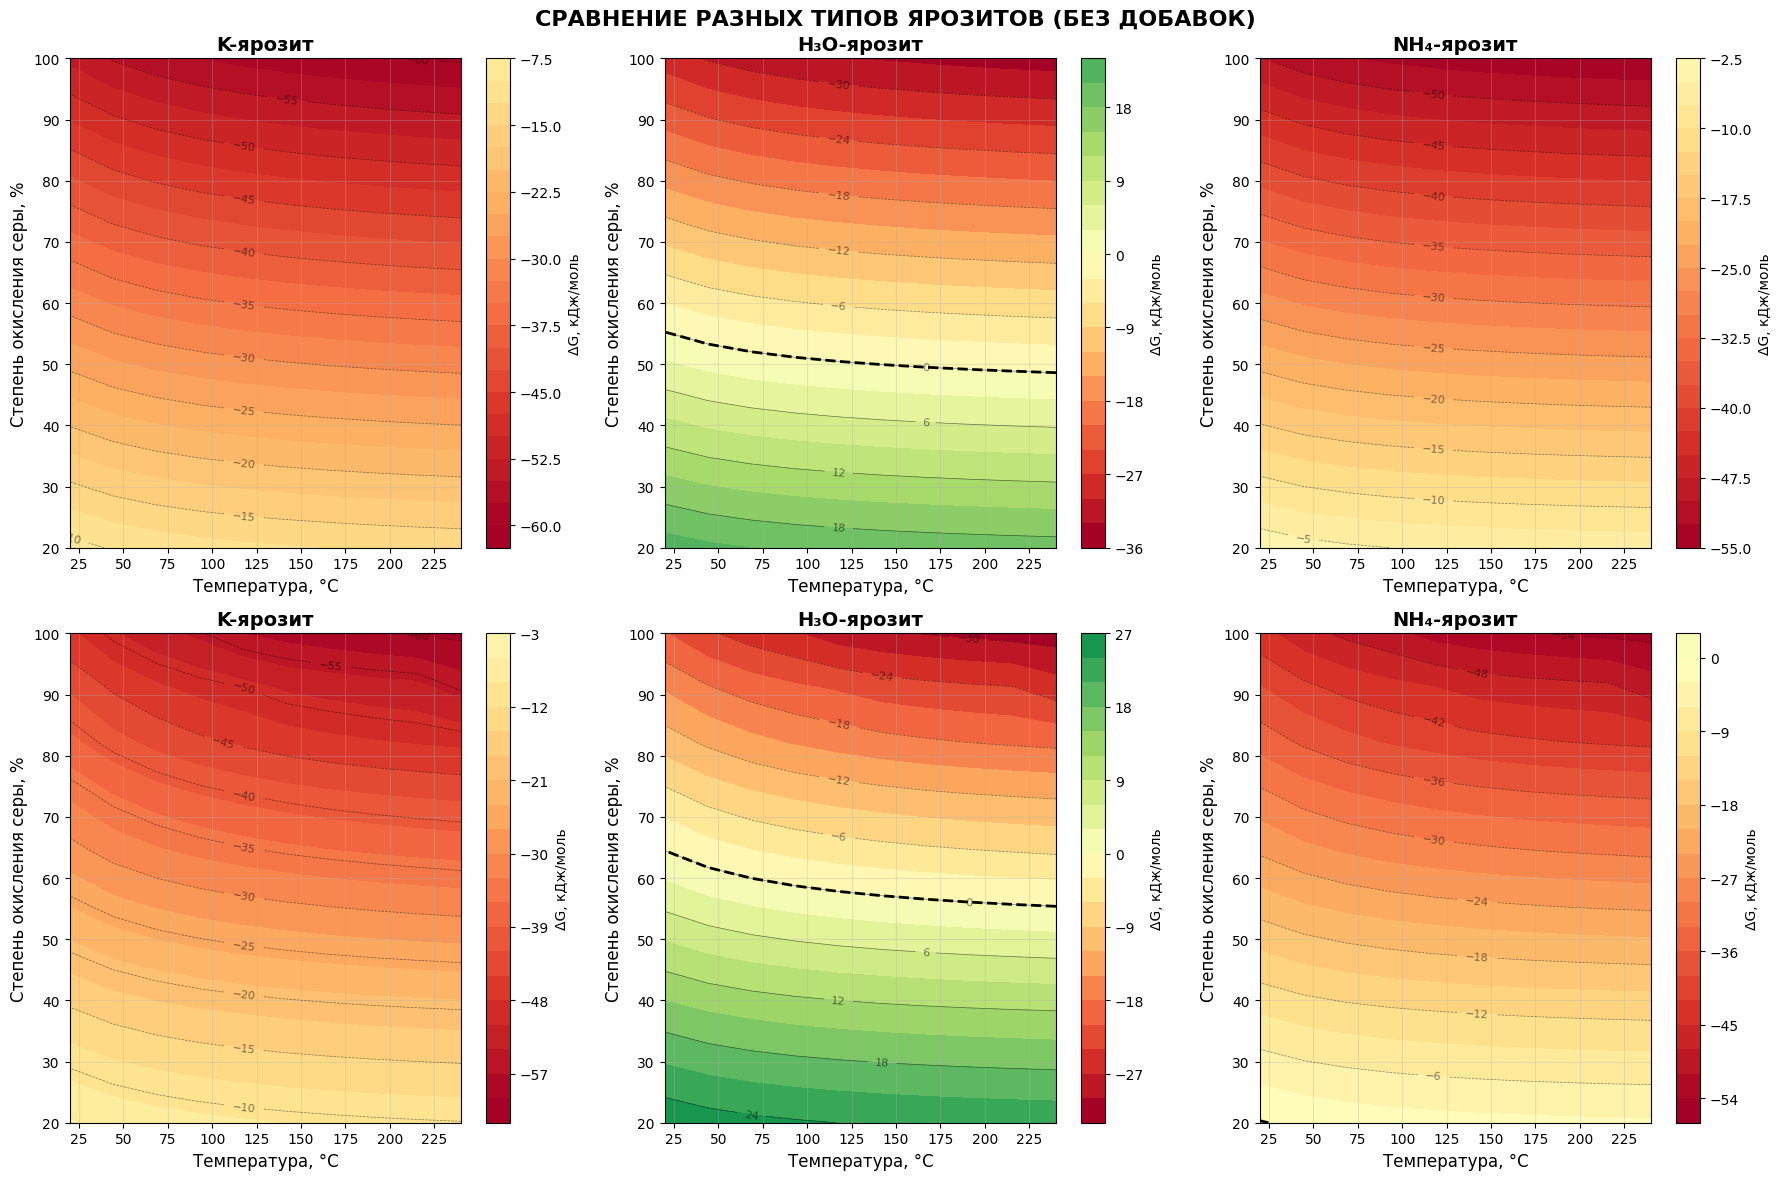

In [ ]:

fig_compare, axes_compare = plt.subplots(2, 3, figsize=(18, 12))
fig_compare.suptitle('СРАВНЕНИЕ РАЗНЫХ ТИПОВ ЯРОЗИТОВ (БЕЗ ДОБАВОК)', 
                     fontsize=16, fontweight='bold')


X, Y = np.meshgrid(temps_range - 273.15, S_Ox_range * 100)

scenario = 'no_add'

for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[0, idx]

    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_simple']

    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
   
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[1, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_full']
    
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

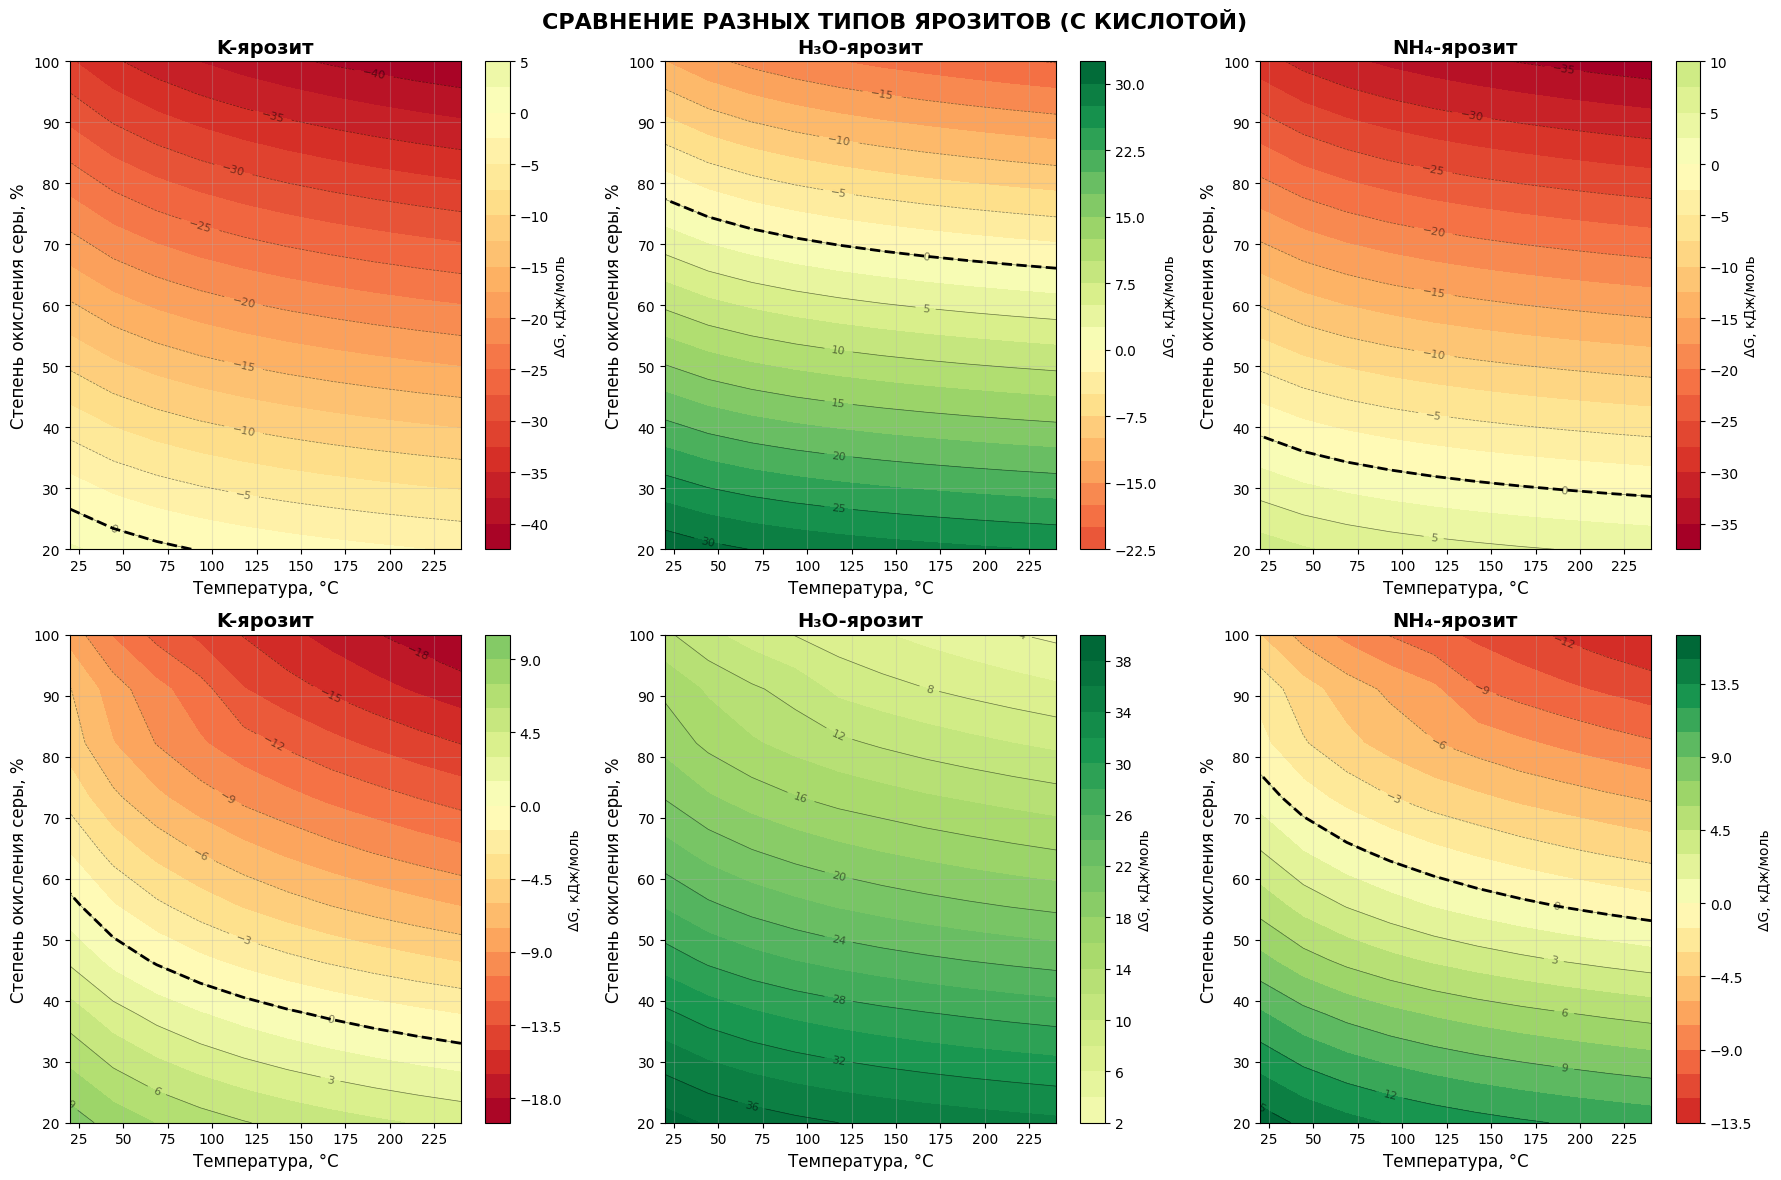

In [ ]:

fig_compare, axes_compare = plt.subplots(2, 3, figsize=(18, 12))
fig_compare.suptitle('СРАВНЕНИЕ РАЗНЫХ ТИПОВ ЯРОЗИТОВ (C КИСЛОТОЙ)', 
                     fontsize=16, fontweight='bold')


X, Y = np.meshgrid(temps_range - 273.15, S_Ox_range * 100)

scenario = 'with_acid'

for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[0, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_simple']
    
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
   
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[1, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_full']
    
    # Находим максимум для симметричной шкалы
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

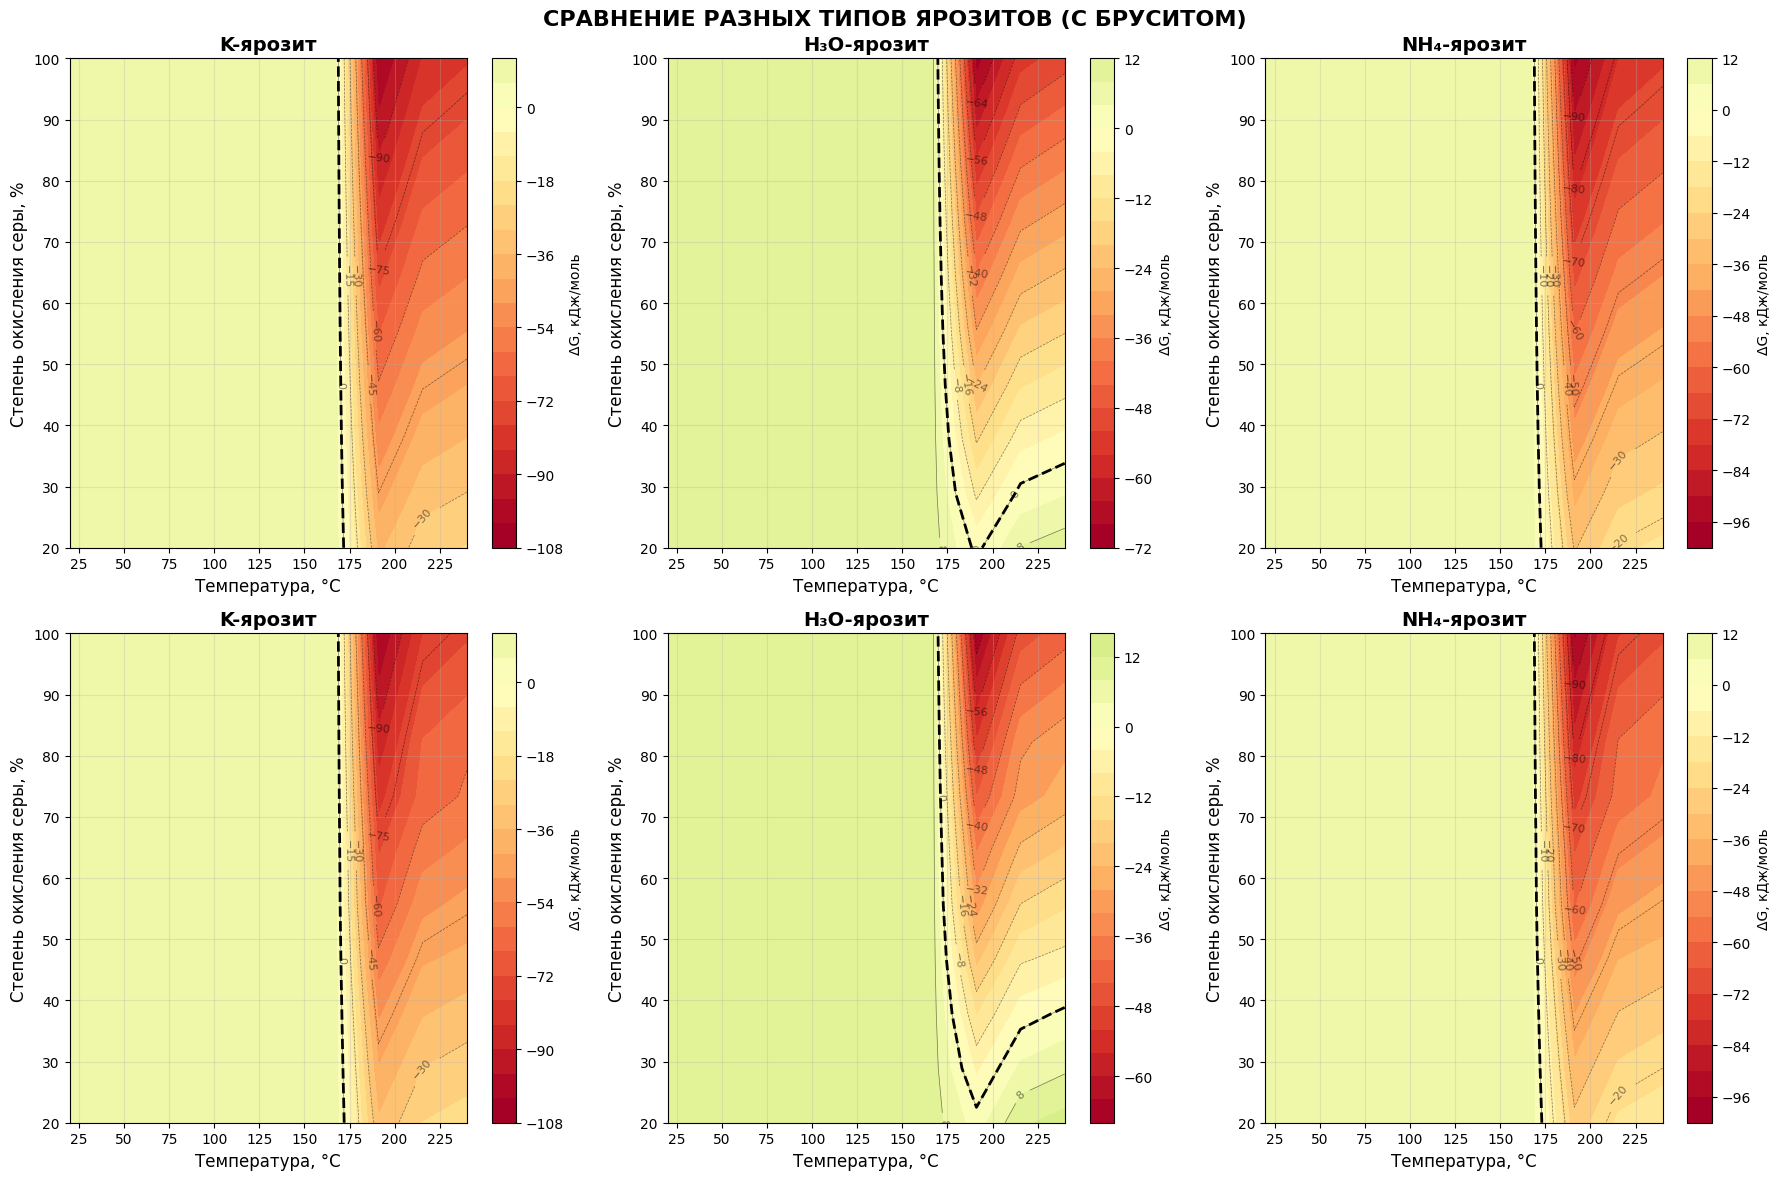

In [ ]:

fig_compare, axes_compare = plt.subplots(2, 3, figsize=(18, 12))
fig_compare.suptitle('СРАВНЕНИЕ РАЗНЫХ ТИПОВ ЯРОЗИТОВ (C БРУСИТОМ)', 
                     fontsize=16, fontweight='bold')


X, Y = np.meshgrid(temps_range - 273.15, S_Ox_range * 100)

scenario = 'with_bruc'

for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[0, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_simple']
    
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
   
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)


for idx, j_type in enumerate(jarosite_types):
    ax = axes_compare[1, idx]
    
    dG_data = np.zeros((len(S_Ox_range), len(temps_range)))
    for i in range(len(S_Ox_range)):
        for j in range(len(temps_range)):
            dG_data[i, j] = results[j_type][scenario]['report'][i, j]['dG_full']
    
    # Находим максимум для симметричной шкалы
    max_abs = np.max(np.abs(dG_data))
    
    contour = ax.contourf(X, Y, dG_data.T, levels=20, cmap='RdYlGn', 
                          vmin=-max_abs, vmax=max_abs)
    plt.colorbar(contour, ax=ax, label='ΔG, кДж/моль')
    
    contour_lines = ax.contour(X, Y, dG_data.T, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    ax.clabel(contour_lines, inline=True, fontsize=8)
    
    ax.contour(X, Y, dG_data.T, levels=[0], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel('Температура, °C', fontsize=12)
    
    ax.set_ylabel('Степень окисления серы, %', fontsize=12)
    
    ax.set_title(jarosite_params[j_type]['name'], fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

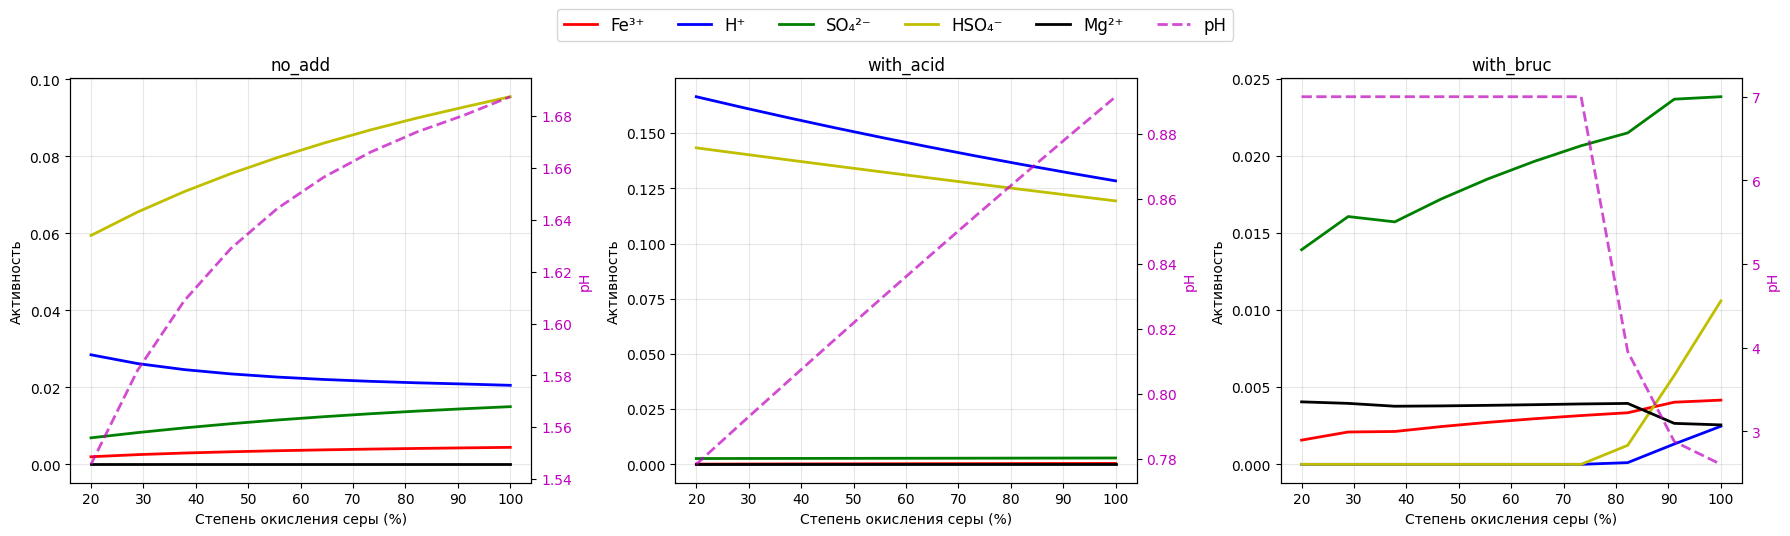

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

TEMP_IDX = 5 

for idx, scenario in enumerate(scenarios):
    ax = axes_act[idx]
    
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_Fe3'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Fe³⁺')
    line2 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_H'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_SO4'] for r in jar_data[:, TEMP_IDX]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_HSO4'] for r in jar_data[:, TEMP_IDX]], 
                   'y-', linewidth=2, label='HSO₄⁻')
    line5 = ax.plot(S_Ox_grid[:, 0]*100, [r['a_Mg2'] for r in jar_data[:, TEMP_IDX]], 
                   'black', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Степень окисления серы (%)')
    ax.set_ylabel('Активность')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{scenario}')
    
    ax2 = ax.twinx()
    line6 = ax2.plot(S_Ox_grid[:, 0]*100, [r['pH'] for r in jar_data[:, TEMP_IDX]], 
                    'm--', linewidth=2, label='pH', alpha=0.7)
    ax2.set_ylabel('pH', color='m')
    ax2.tick_params(axis='y', labelcolor='m')
    
    if idx == 0:
        lines = [line1[0], line2[0], line3[0], line4[0], line5[0], line6[0]]

labels = ['Fe³⁺', 'H⁺', 'SO₄²⁻', 'HSO₄⁻', 'Mg²⁺', 'pH']
fig_act.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=12)
plt.tight_layout()
plt.show()

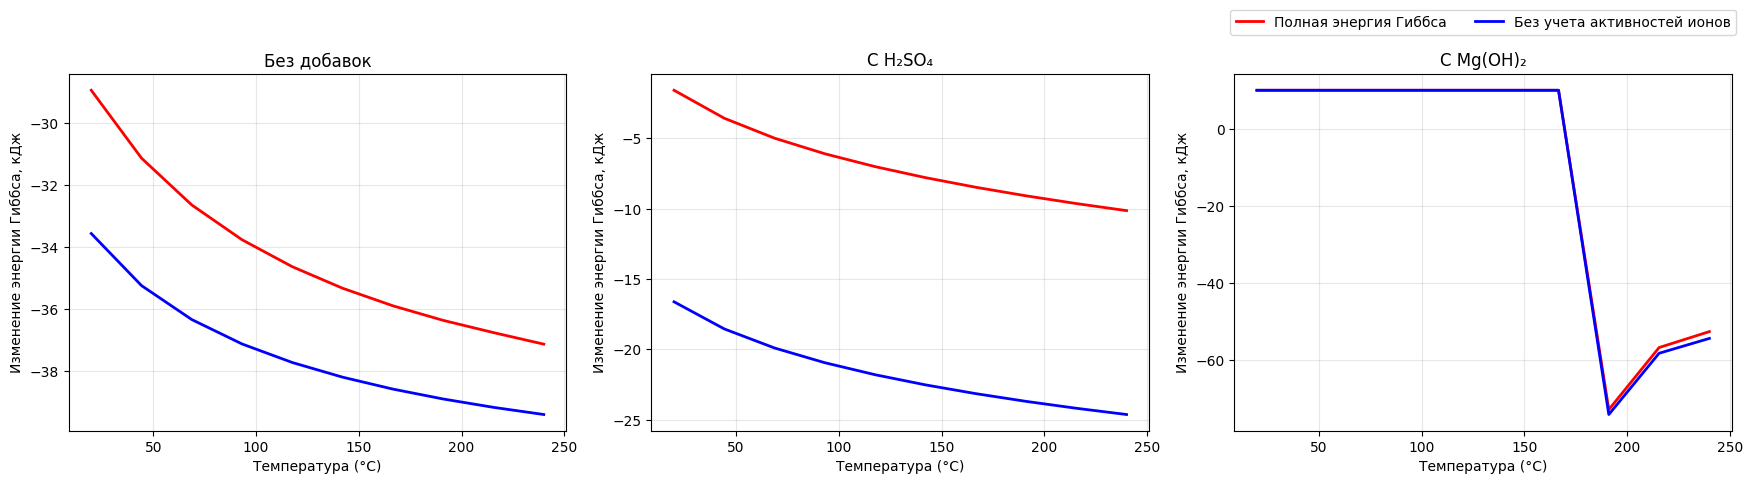

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

S_Ox_IDX = 3 

for i, scenario in enumerate(scenarios):
    
    ax = axes_act[i]
    
    jar_data = results['K'][scenario]['report'] 
    
    temp_c = T_grid[0, :] - 273.15
    
    line1 = ax.plot(temp_c, [r['dG_full'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Энергия Гиббса (полная)')
    line2 = ax.plot(temp_c, [r['dG_simple'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='Энергия Гиббса (без учета активностей)')
   
    ax.set_xlabel('Температура (°C)')
    ax.set_ylabel('Изменение энергии Гиббса, кДж')
    ax.grid(True, alpha=0.3)
    
    ax2.tick_params(axis='y', labelcolor='m')
    
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')

ax.legend(handles=[line1[0], line2[0]],
              labels=['Полная энергия Гиббса', 'Без учета активностей ионов'],
              loc='upper center', bbox_to_anchor=(0.5, 1.2),
                ncol=5)

plt.tight_layout()
plt.show()

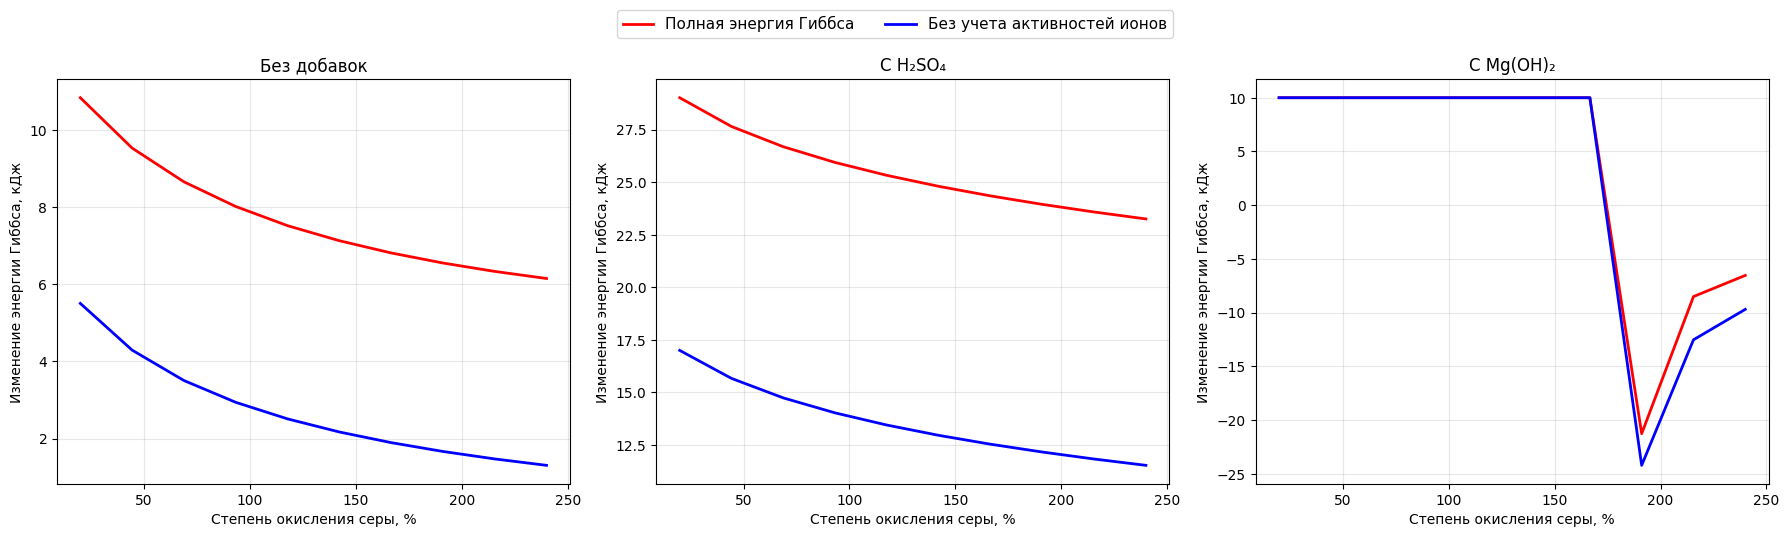

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

TEMP_IDX = 3  

for i, scenario in enumerate(scenarios):
    ax = axes_act[i]
    jar_data = results['H3O'][scenario]['report'] 
    
    
    temp_c = T_grid[0, :] - 273.15
    
    line1 = ax.plot(temp_c, [r['dG_full'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Энергия Гиббса (полная)')
    line2 = ax.plot(temp_c, [r['dG_simple'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='Энергия Гиббса (без учета активностей)')
   
    ax.set_xlabel('Степень окисления серы, %')
    ax.set_ylabel('Изменение энергии Гиббса, кДж')
    ax.grid(True, alpha=0.3)
    
    ax2.tick_params(axis='y', labelcolor='m')
    
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')

fig_act.legend(handles=[line1[0], line2[0]],
              labels=['Полная энергия Гиббса', 'Без учета активностей ионов'],
              loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=4, fontsize=11)

plt.tight_layout()
plt.show()

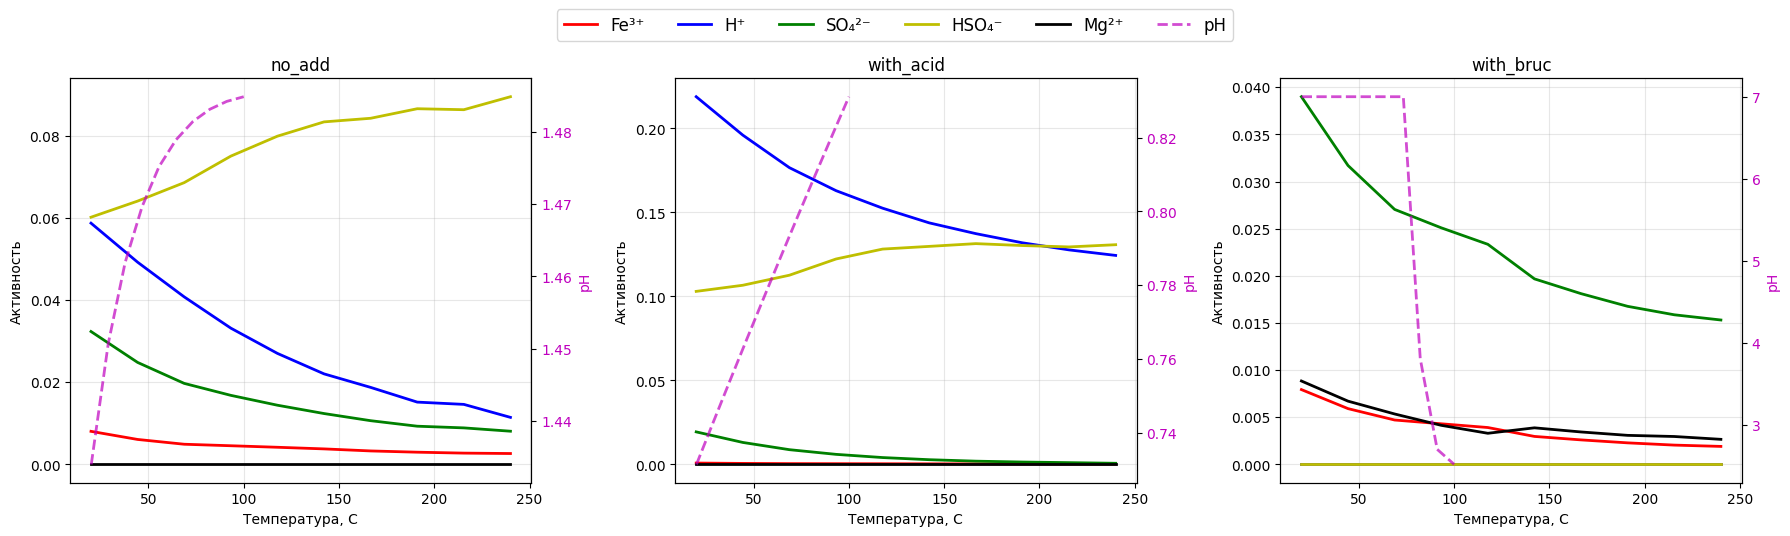

In [ ]:
fig_act, axes_act = plt.subplots(1, 3, figsize=(18, 5))

S_Ox_IDX = 5 

for idx, scenario in enumerate(scenarios):
    ax = axes_act[idx]
    
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(temp_c, [r['a_Fe3'] for r in jar_data[S_Ox_IDX, :]], 
                   'r-', linewidth=2, label='Fe³⁺')
    line2 = ax.plot(temp_c, [r['a_H'] for r in jar_data[S_Ox_IDX, :]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(temp_c, [r['a_SO4'] for r in jar_data[S_Ox_IDX, :]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(temp_c, [r['a_HSO4'] for r in jar_data[S_Ox_IDX, :]], 
                   'y-', linewidth=2, label='HSO₄⁻')
    line5 = ax.plot(temp_c, [r['a_Mg2'] for r in jar_data[S_Ox_IDX, :]], 
                   'black', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Температура, С')
    ax.set_ylabel('Активность')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{scenario}')
    
    ax2 = ax.twinx()
    line6 = ax2.plot(S_Ox_grid[:, 0]*100, [r['pH'] for r in jar_data[:, TEMP_IDX]], 
                    'm--', linewidth=2, label='pH', alpha=0.7)
    ax2.set_ylabel('pH', color='m')
    ax2.tick_params(axis='y', labelcolor='m')
    
    if idx == 0:
        lines = [line1[0], line2[0], line3[0], line4[0], line5[0], line6[0]]

labels = ['Fe³⁺', 'H⁺', 'SO₄²⁻', 'HSO₄⁻', 'Mg²⁺', 'pH']
fig_act.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=6, fontsize=12)
plt.tight_layout()
plt.show()

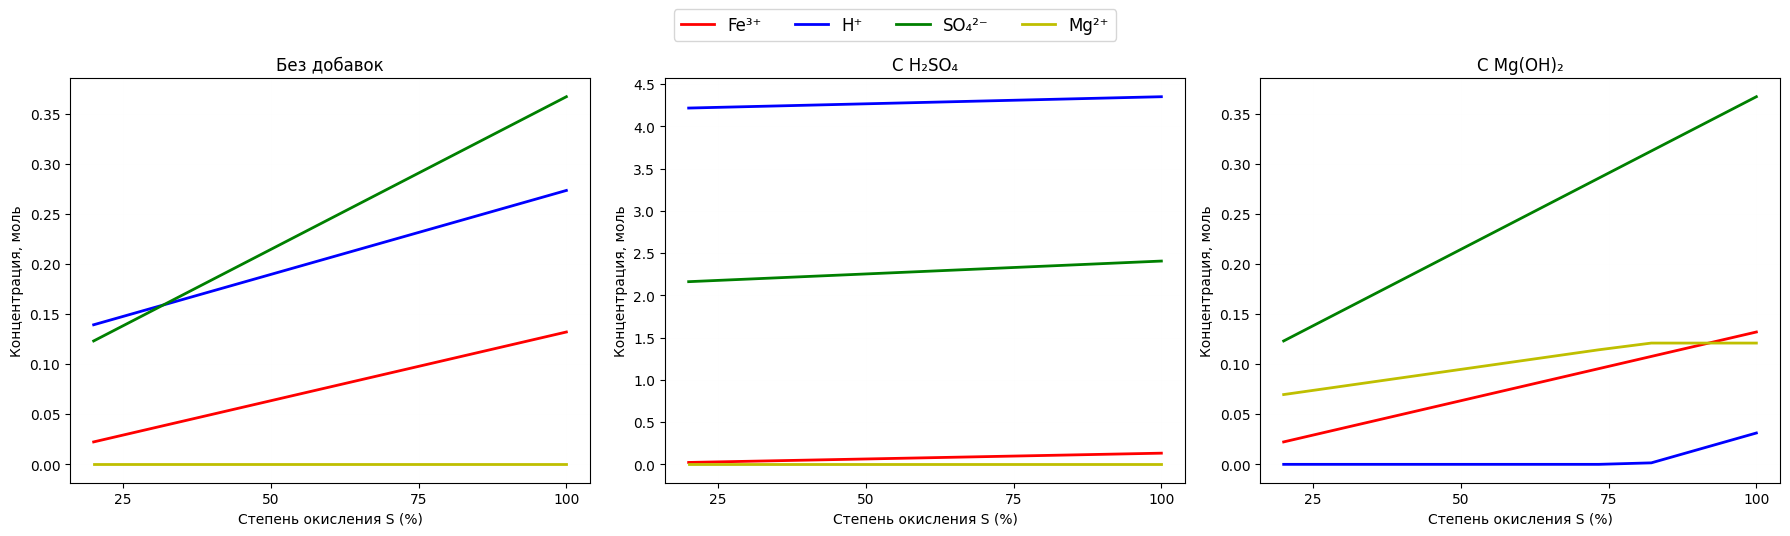

In [ ]:
fig_conc, axes_conc = plt.subplots(1, 3, figsize=(18, 5))

TEMP_IDX = 5  

for i, scenario in enumerate(scenarios):
    ax = axes_conc[i]
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_Fe3'] for r in jar_data[:, TEMP_IDX]], 
                   'r-', linewidth=2, label='Fe³⁺')

    line2 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_H'] for r in jar_data[:, TEMP_IDX]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_SO4'] for r in jar_data[:, TEMP_IDX]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(S_Ox_grid[:, 0]*100, [r['C_Mg2'] for r in jar_data[:, TEMP_IDX]], 
                   'y-', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Степень окисления S (%)')
    ax.set_ylabel('Концентрация, моль')
    ax.grid(True, alpha=0.01)
    ax.locator_params(axis='x', nbins=4) 
    ax.locator_params(axis='y', nbins=10) 
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')


fig_conc.legend(handles=[line1[0], line2[0], line3[0],line4[0]], 
              labels=['Fe³⁺', 'H⁺', 'SO₄²⁻','Mg²⁺'],
              loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=4, fontsize=12)
    

plt.tight_layout()
plt.show()

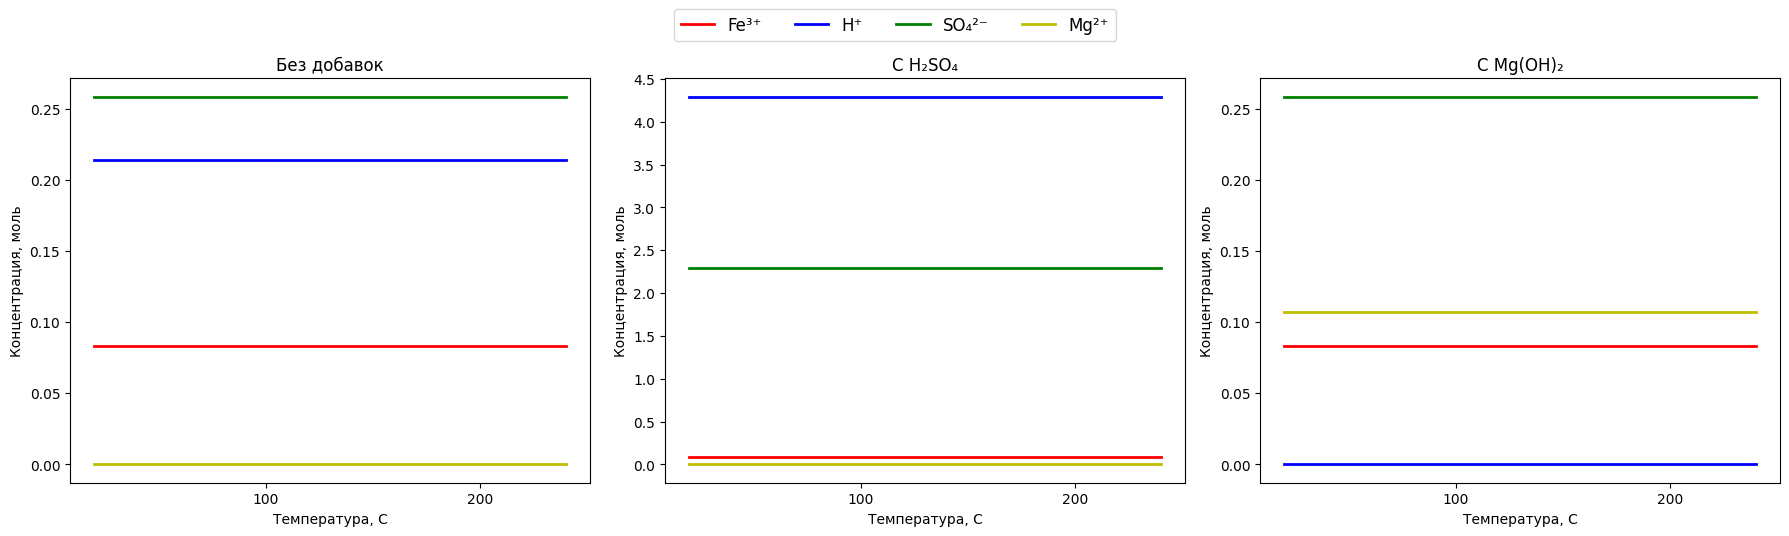

In [ ]:
fig_conc, axes_conc = plt.subplots(1, 3, figsize=(18, 5))

S_Ox_IDX = 5  

for i, scenario in enumerate(scenarios):
    ax = axes_conc[i]
    jar_data = results['K'][scenario]['report'] 
    
    line1 = ax.plot(temp_c, [r['C_Fe3'] for r in jar_data[S_Ox_IDX, :]], 
                   'r-', linewidth=2, label='Fe³⁺')

    line2 = ax.plot(temp_c, [r['C_H'] for r in jar_data[S_Ox_IDX, :]], 
                   'b-', linewidth=2, label='H⁺')
    line3 = ax.plot(temp_c, [r['C_SO4'] for r in jar_data[S_Ox_IDX, :]], 
                   'g-', linewidth=2, label='SO₄²⁻')
    line4 = ax.plot(temp_c, [r['C_Mg2'] for r in jar_data[S_Ox_IDX, :]], 
                   'y-', linewidth=2, label='Mg²⁺')
    
    ax.set_xlabel('Температура, С')
    ax.set_ylabel('Концентрация, моль')
    ax.grid(True, alpha=0.01)
    ax.locator_params(axis='x', nbins=4) 
    ax.locator_params(axis='y', nbins=10) 
    scenario_names = {'no_add': 'Без добавок', 
                      'with_acid': 'С H₂SO₄', 
                      'with_bruc': 'С Mg(OH)₂'}
    ax.set_title(f'{scenario_names.get(scenario, scenario)}')


fig_conc.legend(handles=[line1[0], line2[0], line3[0],line4[0]], 
              labels=['Fe³⁺', 'H⁺', 'SO₄²⁻','Mg²⁺'],
              loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=4, fontsize=12)
    

plt.tight_layout()
plt.show()

In [ ]:
import nbformat
from nbconvert import HTMLExporter
import os
import webbrowser
from datetime import datetime

# Читаем notebook
#with open('code_notebook.ipynb', 'r', encoding='utf-8') as f:
    #notebook = nbformat.read(f, as_version=4)

# Конвертируем в HTML
#html_exporter = HTMLExporter()
#html_exporter.exclude_input = False 
#body, resources = html_exporter.from_notebook_node(notebook)

# Сохраняем с уникальным именем
#filename = f"jarosite_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
#with open(filename, 'w', encoding='utf-8') as f:
    #f.write(body)

#print(f"✅ Отчет сохранен: {os.path.abspath(filename)}")
#print(f"📊 Размер файла: {os.path.getsize(filename)} байт")
#webbrowser.open(filename)

✅ Отчет сохранен: f:\Термодинамика процесса гидролиза\Python\jarosite_report_20260220_141802.html
📊 Размер файла: 3973444 байт


True